In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh_tridiagonal

Primeros niveles de energía:

Estado 1 : -13.603576896436314 eV
Estado 2 : -3.40129227496708 eV
Estado 3 : -1.5117180165710757 eV
Estado 4 : -0.8491052824953828 eV
Estado 5 : -0.48611995968748584 eV

Valores teóricos:

n = 1 : -13.6 eV
n = 2 : -3.4 eV
n = 3 : -1.511111111111111 eV
n = 4 : -0.85 eV
n = 5 : -0.544 eV


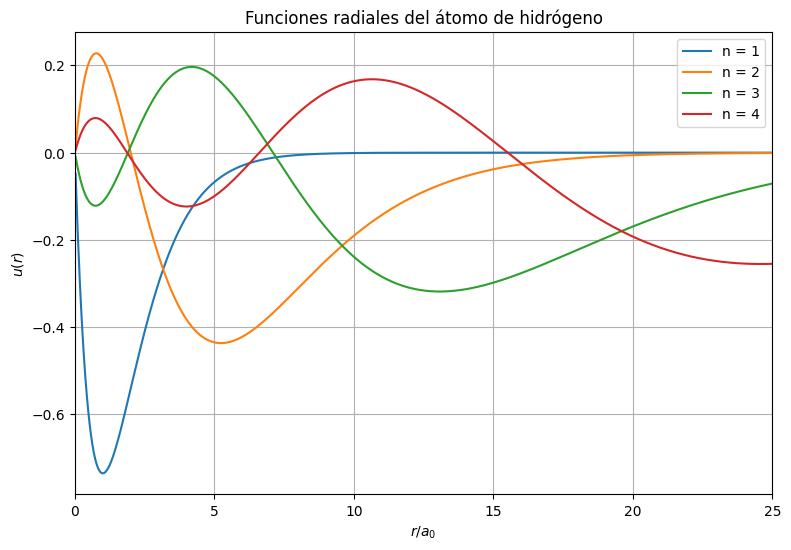

In [2]:

N = 2000          # número de puntos
x_max = 50        # distancia máxima en unidades de a0

dx = x_max / (N + 1)

x = np.arange(1, N + 1) * dx

l = 0

V = -1/x + l*(l+1)/(2*x**2)

diagonal = 1/dx**2 + V
off_diagonal = -1/(2*dx**2)

energies, wavefunctions = eigh_tridiagonal(
    diagonal,
    np.full(N-1, off_diagonal)
)

print("Primeros niveles de energía:")
print()

for i in range(5):
    energy_eV = energies[i] * 27.2114
    print("Estado", i+1, ":", energy_eV, "eV")


print()
print("Valores teóricos:")
print()

for n in range(1, 6):
    E_teorica = -13.6 / n**2
    print("n =", n, ":", E_teorica, "eV")

plt.figure(figsize=(9,6))

for i in range(4):
    u = wavefunctions[:, i]

    u = u / np.sqrt(np.sum(u**2) * dx)

    plt.plot(
        x,
        u,
        label=f"n = {i+1}"
    )

plt.xlabel(r"$r/a_0$")
plt.ylabel(r"$u(r)$")
plt.title("Funciones radiales del átomo de hidrógeno")
plt.xlim(0, 25)
plt.grid()
plt.legend()
plt.show()

l = 0
n = 0
E = -13.603576896436314 eV

l = 1
n = 0
E = -3.4014692493554506 eV

l = 2
n = 0
E = -1.511746161142595 eV



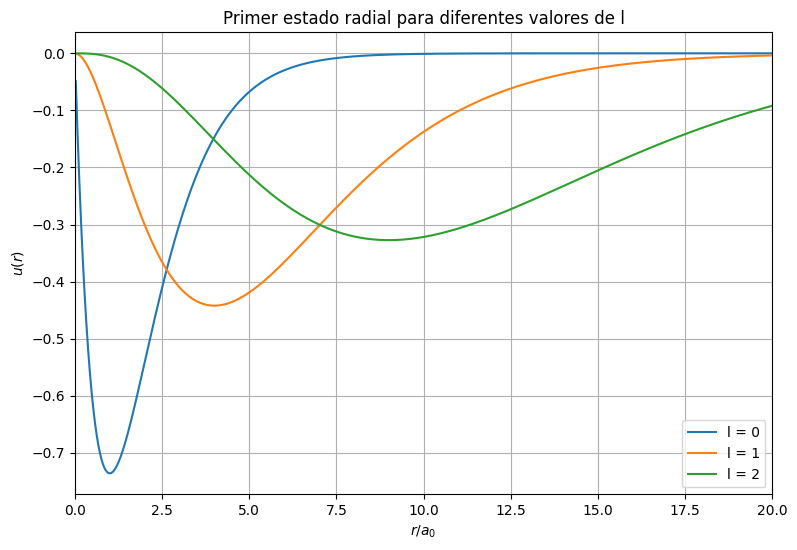

In [3]:
N = 2000
x_max = 50

dx = x_max / (N + 1)

x = np.arange(1, N + 1) * dx

valores_l = [0, 1, 2]

plt.figure(figsize=(9,6))

for l in valores_l:

    # Potencial efectivo
    V = -1/x + l*(l+1)/(2*x**2)

    # Diagonal principal
    diagonal = 1/dx**2 + V

    # Diagonal secundaria
    off_diagonal = -1/(2*dx**2)

    # Resolver H u = E u
    energies, wavefunctions = eigh_tridiagonal(
        diagonal,
        np.full(N-1, off_diagonal)
    )

    n = 0

    E = energies[n]

    u = wavefunctions[:, n]

    # Normalización
    u = u / np.sqrt(np.sum(u**2) * dx)


    E_eV = E * 27.2114

    print("l =", l)
    print("n =", n)
    print("E =", E_eV, "eV")
    print()


    plt.plot(
        x,
        u,
        label=f"l = {l}"
    )

plt.xlabel(r"$r/a_0$")
plt.ylabel(r"$u(r)$")
plt.title("Primer estado radial para diferentes valores de l")

plt.xlim(0, 20)

plt.grid()
plt.legend()

plt.show()